In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import Packages
import os
import glob
import numpy as np # Used to work with arrays
import pandas as pd # Used to work with datasets

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Signal Processing
from scipy.signal import butter, filtfilt

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Set path and load data
path = '/content/drive/MyDrive/EMG-Data/RSE-emg-data'

def load_all_rse_data(base_path):
    all_data = []
    user_folders = glob.glob(os.path.join(base_path, 'User *'))

    for user_folder in user_folders:
        user_id = os.path.basename(user_folder)
        gesture_folders = glob.glob(os.path.join(user_folder, '*'))
        for gesture_folder in gesture_folders:
            gesture_name = os.path.basename(gesture_folder)
            csv_files = glob.glob(os.path.join(gesture_folder, '*.csv'))
            for file in csv_files:
                df = pd.read_csv(file)

                # --- PHẦN FIX LỖI TẠI ĐÂY ---
                # Chuyển tên cột về chữ thường để dễ bắt lỗi
                df.columns = df.columns.str.lower()

                # Bỏ cột 'slno' hoặc 'time' nếu có tồn tại trong file
                cols_to_drop = [col for col in df.columns if 'slno' in col or 'time' in col]
                df = df.drop(columns=cols_to_drop, errors='ignore')
                # ----------------------------

                # Lấy kênh EMG
                numeric_cols = df.select_dtypes(include=[np.number]).columns
                df_clean = df[numeric_cols]
                df_clean['User'] = user_id
                df_clean['Gesture'] = gesture_name
                all_data.append(df_clean)

    return pd.concat(all_data, ignore_index=True)

df_emg = load_all_rse_data(path)
print("Các cột còn lại: ", df_emg.columns.tolist())

Các cột còn lại:  ['emg1', 'emg2', 'emg3', 'emg4', 'emg5', 'emg6', 'emg7', 'emg8', 'User', 'Gesture']


In [4]:
# Show part of the data
df_emg.head()

,emg1,emg2,emg3,emg4,emg5,emg6,emg7,emg8,User,Gesture
0,3,-2,-2,-1,0,-1,4,1,User 1,Cylindrical Grip
1,-1,0,5,3,-1,-1,-2,0,User 1,Cylindrical Grip
2,-1,-2,-1,1,1,0,-1,-2,User 1,Cylindrical Grip
3,-1,-2,-2,-1,-2,-1,-4,-1,User 1,Cylindrical Grip
4,-1,-2,-1,0,0,-1,-2,-1,User 1,Cylindrical Grip


In [5]:
# print about information
df_emg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3980063 entries, 0 to 3980062
Data columns (total 10 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   emg1     int64 
 1   emg2     int64 
 2   emg3     int64 
 3   emg4     int64 
 4   emg5     int64 
 5   emg6     int64 
 6   emg7     int64 
 7   emg8     int64 
 8   User     object
 9   Gesture  object
dtypes: int64(8), object(2)
memory usage: 303.7+ MB


In [6]:
# check is null data
df_emg.isnull().sum()

,0
emg1,0
emg2,0
emg3,0
emg4,0
emg5,0
emg6,0
emg7,0
emg8,0
User,0
Gesture,0


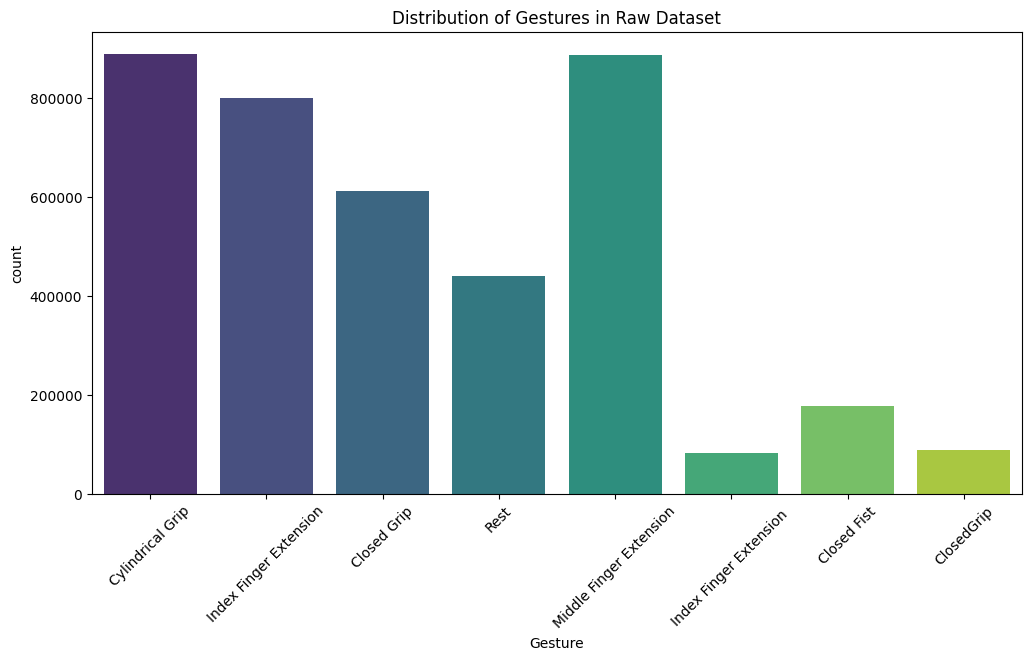

,count
Gesture,
Cylindrical Grip,889784
Middle Finger Extension,888158
Index Finger Extension,801001
Closed Grip,612781
Rest,440738
Closed Fist,176846
ClosedGrip,87711
Index Finger Extension,83044


In [7]:
# The number of records in each gesture using bars.
plt.figure(figsize=(12, 6))
sns.countplot(data=df_emg, x='Gesture', palette='viridis')
plt.title('Distribution of Gestures in Raw Dataset')
plt.xticks(rotation=45)
plt.show()

df_emg['Gesture'].value_counts()

In [8]:
# print description of raw sensor values
df_emg.describe().T

,count,mean,std,min,25%,50%,75%,max
emg1,3980063.0,-0.720376,10.967611,-128.0,-2.0,-1.0,1.0,127.0
emg2,3980063.0,-0.804870,11.482479,-128.0,-2.0,-1.0,1.0,127.0
emg3,3980063.0,-0.824694,12.188025,-128.0,-2.0,-1.0,1.0,127.0
emg4,3980063.0,-0.826479,15.224588,-128.0,-2.0,-1.0,1.0,127.0
emg5,3980063.0,-0.885538,10.194493,-128.0,-2.0,-1.0,0.0,127.0
emg6,3980063.0,-0.761142,5.404534,-128.0,-2.0,-1.0,0.0,127.0
emg7,3980063.0,-0.720636,7.694540,-128.0,-2.0,-1.0,0.0,127.0
emg8,3980063.0,-0.755061,10.543326,-128.0,-2.0,-1.0,0.0,127.0


Danh sách User: ['User 1' 'User 5' 'User 10' 'User 2' 'User 9' 'User 4' 'User 6' 'User 7'
 'User 3' 'User 8']
Danh sách Gesture: ['Cylindrical Grip' 'Index Finger Extension' 'Closed Grip' 'Rest'
 'Middle Finger Extension' 'Index Finger Extension ' 'Closed Fist'
 'ClosedGrip']


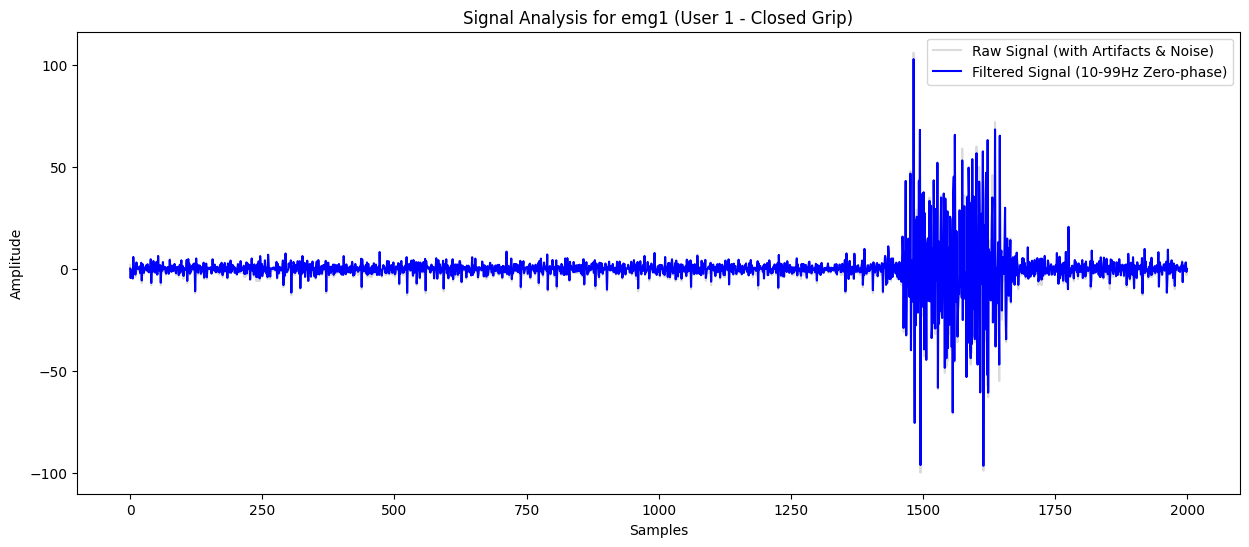

In [9]:
# 1. In ra danh sách User và Gesture thực tế trong DataFrame để đối chiếu
print("Danh sách User:", df_emg['User'].unique())
print("Danh sách Gesture:", df_emg['Gesture'].unique())

# 2. Chọn User và Gesture (Lưu ý: User 1 dùng 'Closed Grip' theo tên thư mục)
target_user = 'User 1'
target_gesture = 'Closed Grip'

sample_data = df_emg[(df_emg['User'] == target_user) & (df_emg['Gesture'] == target_gesture)].head(2000)

# 3. Lớp phòng thủ: Kiểm tra xem có dữ liệu hay không trước khi lọc
if len(sample_data) == 0:
    print(f"⚠️ KHÔNG TÌM THẤY DỮ LIỆU cho User: '{target_user}' và Gesture: '{target_gesture}'. Hãy check lại tên!")
else:
    ch_name = sample_data.columns[0] # Lấy kênh thứ 2
    raw_signal = sample_data[ch_name].values

    # Hàm filtfilt yêu cầu len(signal) > 3 * max(len(a), len(b)) (tức là > 27)
    if len(raw_signal) > 33:
        # Áp dụng bộ lọc thiết kế theo yêu cầu (Butterworth 4th order, 10-99Hz)
        b, a = butter(4, [10.0 / 100.0, 99.0 / 100.0], btype='band')
        filtered_signal = filtfilt(b, a, raw_signal)

        # Vẽ biểu đồ
        plt.figure(figsize=(15, 6))
        plt.plot(raw_signal, label='Raw Signal (with Artifacts & Noise)', color='lightgray', alpha=0.8)
        plt.plot(filtered_signal, label='Filtered Signal (10-99Hz Zero-phase)', color='blue')
        plt.title(f'Signal Analysis for {ch_name} ({target_user} - {target_gesture})')
        plt.xlabel('Samples')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.show()
    else:
        print(f"⚠️ Tín hiệu quá ngắn ({len(raw_signal)} samples), không đủ độ dài để qua bộ lọc!")

# Data PreProcessing
1. Digital Band-pass Filtering (10-99Hz)
2. Dynamic Segmentation (Window: 200, Step: 10)
3. RMS Feature Extraction

In [10]:
def extract_features_v2(df, window_size=200, step_size=10):
    features = []
    users = df['User'].unique()

    # Lấy tự động các cột tín hiệu (loại bỏ 'User' và 'Gesture')
    signal_cols = [col for col in df.columns if col not in ['User', 'Gesture']]
    num_channels = len(signal_cols)

    print("Bắt đầu trích xuất 4 features (RMS, MAV, SSI, VAR) trên 8 kênh...")
    for user in sorted(users):
        user_data = df[df['User'] == user]
        gestures = user_data['Gesture'].unique()

        for gesture in gestures:
            raw_signal = user_data[user_data['Gesture'] == gesture][signal_cols].values

            # 1. Bandpass Filter (Sử dụng b, a từ Cell trước)
            if len(raw_signal) > 33:
                filtered_signal = filtfilt(b, a, raw_signal, axis=0)
            else:
                filtered_signal = raw_signal

            # 2. Sliding Window
            start = 0
            while start + window_size <= len(filtered_signal):
                window = filtered_signal[start : start + window_size]

                # ------ CÔNG THỨC TRÍCH XUẤT ĐẶC TRƯNG ------
                # 1. RMS (Căn bậc 2 trung bình bình phương)
                rms = np.sqrt(np.mean(window**2, axis=0))

                # 2. MAV (Trung bình giá trị tuyệt đối)
                mav = np.mean(np.abs(window), axis=0)

                # 3. SSI (Tích phân bình phương - Tổng năng lượng)
                ssi = np.sum(window**2, axis=0)

                # 4. VAR (Phương sai - Độ phân tán)
                var = np.var(window, axis=0)
                # ---------------------------------------------

                # Nối tất cả lại (8*4 = 32 features/dòng)
                combined_features = list(rms) + list(mav) + list(ssi) + list(var)

                row = combined_features + [user, gesture]
                features.append(row)
                start += step_size

    # 3. Đặt tên cột tự động cho chuẩn
    feature_cols = []
    for feat_name in ['RMS', 'MAV', 'SSI', 'VAR']:
        for i in range(1, num_channels + 1):
            feature_cols.append(f'Ch_{i}_{feat_name}')

    feature_cols += ['User', 'Gesture']
    features_df = pd.DataFrame(features, columns=feature_cols)

    return features_df

# Chạy Pipeline
df_features = extract_features_v2(df_emg)
df_features.head()

Bắt đầu trích xuất 4 features (RMS, MAV, SSI, VAR) trên 8 kênh...


,Ch_1_RMS,Ch_2_RMS,Ch_3_RMS,Ch_4_RMS,Ch_5_RMS,Ch_6_RMS,Ch_7_RMS,Ch_8_RMS,Ch_1_MAV,Ch_2_MAV,...,Ch_1_VAR,Ch_2_VAR,Ch_3_VAR,Ch_4_VAR,Ch_5_VAR,Ch_6_VAR,Ch_7_VAR,Ch_8_VAR,User,Gesture
0,1.482149,1.422540,2.343247,5.436263,3.727433,1.364975,2.130408,1.183849,1.163674,1.107964,...,2.195584,2.023582,5.490276,29.552915,13.893595,1.863014,4.534971,1.401030,User 1,Cylindrical Grip
1,1.451723,1.412184,2.320410,5.443153,3.723812,1.445572,2.043387,1.164826,1.143480,1.102809,...,2.107297,1.994094,5.384276,29.627904,13.866307,2.089581,4.175138,1.356749,User 1,Cylindrical Grip
2,1.439046,1.397051,2.341025,5.538955,3.720620,1.434155,2.015549,1.167489,1.129757,1.088304,...,2.070652,1.951749,5.480374,30.678952,13.842788,2.056796,4.062348,1.363024,User 1,Cylindrical Grip
3,1.415595,1.361977,2.329644,5.551269,3.701217,1.499856,2.049440,1.157642,1.136603,1.061808,...,2.003885,1.854981,5.427069,30.815496,13.697841,2.249511,4.200201,1.339940,User 1,Cylindrical Grip
4,1.399403,1.372019,2.315924,5.473659,3.721006,1.562720,2.048609,1.144584,1.132756,1.064830,...,1.958317,1.882281,5.363506,29.960918,13.845266,2.442051,4.196798,1.310029,User 1,Cylindrical Grip


In [11]:
# ==========================================
# FIX LỖI "RÁC NHÃN" (DIRTY LABELS)
# ==========================================

print("Danh sách nhãn CŨ (Chứa nhiều rác/khoảng trắng):")
print(df_features['Gesture'].unique())

# 1. Cắt bỏ mọi khoảng trắng vô hình ở đầu và cuối chuỗi (Xử lý lỗi 'Index Finger Extension ')
df_features['Gesture'] = df_features['Gesture'].str.strip()

# 2. Quy chuẩn các cách viết khác nhau về cùng 1 tên chuẩn (Gom nhóm Closed Fist)
label_mapping = {
    'Closed Grip': 'Closed Fist',
    'ClosedGrip': 'Closed Fist'
}
df_features['Gesture'] = df_features['Gesture'].replace(label_mapping)

print("\nDanh sách nhãn MỚI (Đã chuẩn hóa, phải chốt lại đúng 5 cử chỉ):")
print(df_features['Gesture'].unique())

Danh sách nhãn CŨ (Chứa nhiều rác/khoảng trắng):
['Cylindrical Grip' 'Index Finger Extension' 'Closed Grip' 'Rest'
 'Middle Finger Extension' 'Index Finger Extension ' 'ClosedGrip'
 'Closed Fist']

Danh sách nhãn MỚI (Đã chuẩn hóa, phải chốt lại đúng 5 cử chỉ):
['Cylindrical Grip' 'Index Finger Extension' 'Closed Fist' 'Rest'
 'Middle Finger Extension']


In [12]:
from sklearn.preprocessing import MinMaxScaler

def prepare_data_minmax(features_df):
    print("Đang chia Train/Test theo Rule RSE Dataset (User 10 = Test)...")

    # Chia User
    train_df = features_df[features_df['User'] != 'User 10']
    test_df = features_df[features_df['User'] == 'User 10']

    # Tách X (Features) và y (Labels)
    X_train = train_df.drop(columns=['User', 'Gesture'])
    y_train = train_df['Gesture']

    X_test = test_df.drop(columns=['User', 'Gesture'])
    y_test = test_df['Gesture']

    print("Đang Scale dữ liệu bằng MinMaxScaler (Range: 0 -> 1)...")
    scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit scaler chỉ trên Train, sau đó transform
    X_train_scaled = scaler.fit_transform(X_train)

    # Chỉ transform trên Test (Không fit lại)
    X_test_scaled = scaler.transform(X_test)

    # Tùy chọn: Chuyển lại thành DataFrame để dễ in ấn và debug
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

    return X_train_scaled, X_test_scaled, y_train, y_test

# Khởi chạy hàm
X_train_final, X_test_final, y_train, y_test = prepare_data_minmax(df_features)

print(f"\nX_train size: {X_train_final.shape}")
print(f"X_test size: {X_test_final.shape}")

# In thử 5 dòng đầu xem dữ liệu đã bị ép về 0-1 chưa
X_train_final.head()

Đang chia Train/Test theo Rule RSE Dataset (User 10 = Test)...
Đang Scale dữ liệu bằng MinMaxScaler (Range: 0 -> 1)...

X_train size: (358557, 32)
X_test size: (38479, 32)


,Ch_1_RMS,Ch_2_RMS,Ch_3_RMS,Ch_4_RMS,Ch_5_RMS,Ch_6_RMS,Ch_7_RMS,Ch_8_RMS,Ch_1_MAV,Ch_2_MAV,...,Ch_7_SSI,Ch_8_SSI,Ch_1_VAR,Ch_2_VAR,Ch_3_VAR,Ch_4_VAR,Ch_5_VAR,Ch_6_VAR,Ch_7_VAR,Ch_8_VAR
0,0.011187,0.015191,0.027251,0.061440,0.041120,0.009250,0.021094,0.006658,0.010171,0.014396,...,0.000880,0.000160,0.000354,0.000388,0.001350,0.004791,0.002443,0.000261,0.000880,0.000159
1,0.010740,0.015042,0.026871,0.061529,0.041071,0.010373,0.019793,0.006409,0.009820,0.014306,...,0.000801,0.000152,0.000336,0.000382,0.001321,0.004803,0.002438,0.000304,0.000801,0.000152
2,0.010553,0.014823,0.027214,0.062770,0.041028,0.010214,0.019376,0.006443,0.009581,0.014055,...,0.000776,0.000153,0.000328,0.000373,0.001347,0.004976,0.002433,0.000298,0.000776,0.000153
3,0.010209,0.014318,0.027025,0.062929,0.040763,0.011129,0.019883,0.006314,0.009700,0.013595,...,0.000806,0.000149,0.000314,0.000353,0.001333,0.004999,0.002407,0.000335,0.000806,0.000149
4,0.009971,0.014463,0.026796,0.061924,0.041033,0.012005,0.019871,0.006143,0.009633,0.013648,...,0.000806,0.000144,0.000304,0.000359,0.001316,0.004858,0.002434,0.000371,0.000806,0.000144


In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import gc

# ==========================================
# FIX LỖI RÁC NHÃN CHO df_emg TRƯỚC KHI CẮT
# ==========================================
df_emg['Gesture'] = df_emg['Gesture'].str.strip()
label_mapping = {
    'Closed Grip': 'Closed Fist',
    'ClosedGrip': 'Closed Fist'
}
df_emg['Gesture'] = df_emg['Gesture'].replace(label_mapping)
# ==========================================

# 1. Tách Dataframe gốc thành Train (User 1-9) và Test (User 10)
df_train = df_emg[df_emg['User'] != 'User 10'].copy()
df_test = df_emg[df_emg['User'] == 'User 10'].copy()

def make_3d_tensors(df, window_size=200, step_size=10):
    X_list, y_list = [], []
    signal_cols = [col for col in df.columns if col not in ['User', 'Gesture']]

    for user in df['User'].unique():
        user_data = df[df['User'] == user]
        for gesture in user_data['Gesture'].unique():
            signal = user_data[user_data['Gesture'] == gesture][signal_cols].astype(np.float32).values
            start = 0
            while start + window_size <= len(signal):
                X_list.append(signal[start : start + window_size])
                y_list.append(gesture)
                start += step_size

    X_3d = np.array(X_list, dtype=np.float32)
    del X_list
    gc.collect()
    return X_3d, y_list

print("⏳ Đang cắt Tensor cho tập TRAIN (User 1-9)...")
X_train_dl_raw, y_train_list = make_3d_tensors(df_train)

print("⏳ Đang cắt Tensor cho tập TEST (User 10)...")
X_test_dl_raw, y_test_list = make_3d_tensors(df_test)

# 2. Mã hóa Nhãn (Label Encoding) thống nhất cho cả 2 tập
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_list)
y_train_dl = to_categorical(y_train_encoded)

y_test_encoded = le.transform(y_test_list)
y_test_dl = to_categorical(y_test_encoded)

print(f"✅ X_train (User 1-9): {X_train_dl_raw.shape}")
print(f"✅ X_test (User 10): {X_test_dl_raw.shape}")

⏳ Đang cắt Tensor cho tập TRAIN (User 1-9)...
⏳ Đang cắt Tensor cho tập TEST (User 10)...
✅ X_train (User 1-9): (358557, 200, 8)
✅ X_test (User 10): (38479, 200, 8)


In [14]:
# Lấy 20% của User 10 để cho máy "làm quen" (Calibration), 80% giữ lại để Test thật
X_calib, X_final_test, y_calib, y_final_test = train_test_split(
    X_test_dl_raw, y_test_dl, test_size=0.8, random_state=42, stratify=np.argmax(y_test_dl, axis=1)
)

print(f"Tập Calibration (20% User 10): {X_calib.shape[0]} mẫu")
print(f"Tập Final Test (80% User 10): {X_final_test.shape[0]} mẫu")

Tập Calibration (20% User 10): 7695 mẫu
Tập Final Test (80% User 10): 30784 mẫu


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_advanced_emg_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    attn_out = MultiHeadAttention(num_heads=4, key_dim=128)(x, x)
    x = LayerNormalization()(x + attn_out)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=inputs, outputs=outputs)

# Khởi tạo mô hình (Sử dụng đúng biến X_train_dl_raw)
dl_model = build_advanced_emg_model(
    input_shape=(X_train_dl_raw.shape[1], X_train_dl_raw.shape[2]),
    num_classes=y_train_dl.shape[1]
)

# Compile với Learning Rate lớn (1e-3) để học cái mới từ đầu
dl_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("🚀 BƯỚC 1: PRE-TRAINING (DẠY KIẾN THỨC NỀN TỪ USER 1-9)")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Chạy Pre-training (Chạy thử 10 vòng)
history_pretrain = dl_model.fit(
    X_train_dl_raw, y_train_dl,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop]
)

# Đánh giá sức mạnh của mạng khi chưa cần hiệu chuẩn
print("\n📊 ĐÁNH GIÁ (TRƯỚC KHI HIỆU CHUẨN) TRÊN USER 10 LẠ LẪM:")
dl_model.evaluate(X_final_test, y_final_test)


🚀 BƯỚC 1: PRE-TRAINING (DẠY KIẾN THỨC NỀN TỪ USER 1-9)
Epoch 1/10
2522/2522 ━━━━━━━━━━━━━━━━━━━━ 90s 32ms/step - accuracy: 0.7578 - loss: 0.6237 - val_accuracy: 0.3991 - val_loss: 3.2904
Epoch 2/10
2522/2522 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - accuracy: 0.9083 - loss: 0.2599 - val_accuracy: 0.3004 - val_loss: 5.4796
Epoch 3/10
2522/2522 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9555 - loss: 0.1312 - val_accuracy: 0.3366 - val_loss: 5.6458
Epoch 4/10
2522/2522 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9777 - loss: 0.0688 - val_accuracy: 0.3271 - val_loss: 6.0356

📊 ĐÁNH GIÁ (TRƯỚC KHI HIỆU CHUẨN) TRÊN USER 10 LẠ LẪM:
962/962 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.4001 - loss: 3.1542


[3.154207944869995, 0.4001104533672333]

In [16]:
print("🚀 BƯỚC 2: FINE-TUNING (HIỆU CHUẨN VỚI 20% DỮ LIỆU CỦA USER 10)")

# Đổi Learning Rate nhỏ lại (1e-5) để không phá hỏng kiến thức nền đã học ở Cell 17
dl_model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

history_finetune = dl_model.fit(
    X_calib, y_calib,
    epochs=20,
    batch_size=32,
    validation_data=(X_final_test, y_final_test)
)

print("\n🏆 KẾT QUẢ CUỐI CÙNG SAU KHI FINE-TUNE:")
loss_final, acc_final = dl_model.evaluate(X_final_test, y_final_test)
print(f"🎯 Độ chính xác (Accuracy): {acc_final * 100:.2f}%")

🚀 BƯỚC 2: FINE-TUNING (HIỆU CHUẨN VỚI 20% DỮ LIỆU CỦA USER 10)
Epoch 1/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.5057 - loss: 1.7566 - val_accuracy: 0.5997 - val_loss: 1.0833
Epoch 2/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.6586 - loss: 0.9199 - val_accuracy: 0.7120 - val_loss: 0.7334
Epoch 3/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.7322 - loss: 0.7074 - val_accuracy: 0.7599 - val_loss: 0.6161
Epoch 4/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.7693 - loss: 0.6260 - val_accuracy: 0.7885 - val_loss: 0.5512
Epoch 5/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.7890 - loss: 0.5667 - val_accuracy: 0.8049 - val_loss: 0.5096
Epoch 6/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.8013 - loss: 0.5299 - val_accuracy: 0.8183 - val_loss: 0.4771
Epoch 7/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.8185 - loss: 0.4937 - val_accuracy: 0.8281 - val_loss: 0.4521
Epoch 8/20
241/241 ━━━━━━━━━

⏳ Đang thu thập dự đoán trên tập Final Test...
962/962 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step

📄 BÁO CÁO PHÂN LOẠI CHI TIẾT TỪNG CỬ CHỈ
                         precision    recall  f1-score   support

            Closed Fist       0.98      0.98      0.98      6260
       Cylindrical Grip       0.96      0.96      0.96      7146
 Index Finger Extension       0.85      0.85      0.85      6628
Middle Finger Extension       0.86      0.77      0.81      7178
                   Rest       0.74      0.89      0.81      3572

               accuracy                           0.89     30784
              macro avg       0.88      0.89      0.88     30784
           weighted avg       0.89      0.89      0.89     30784



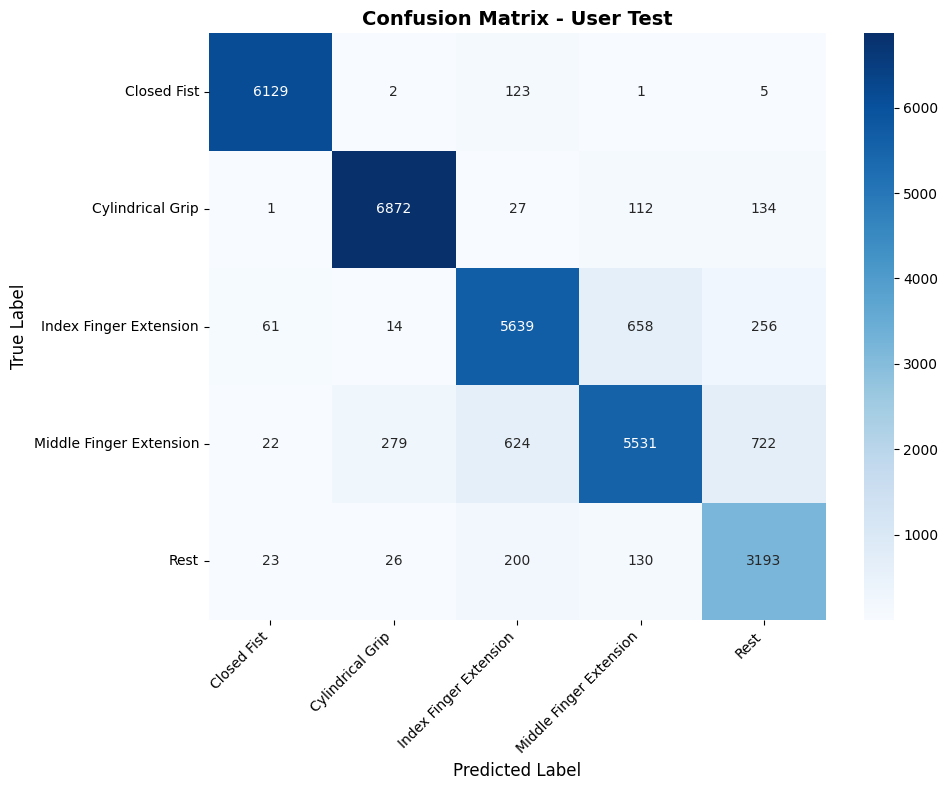

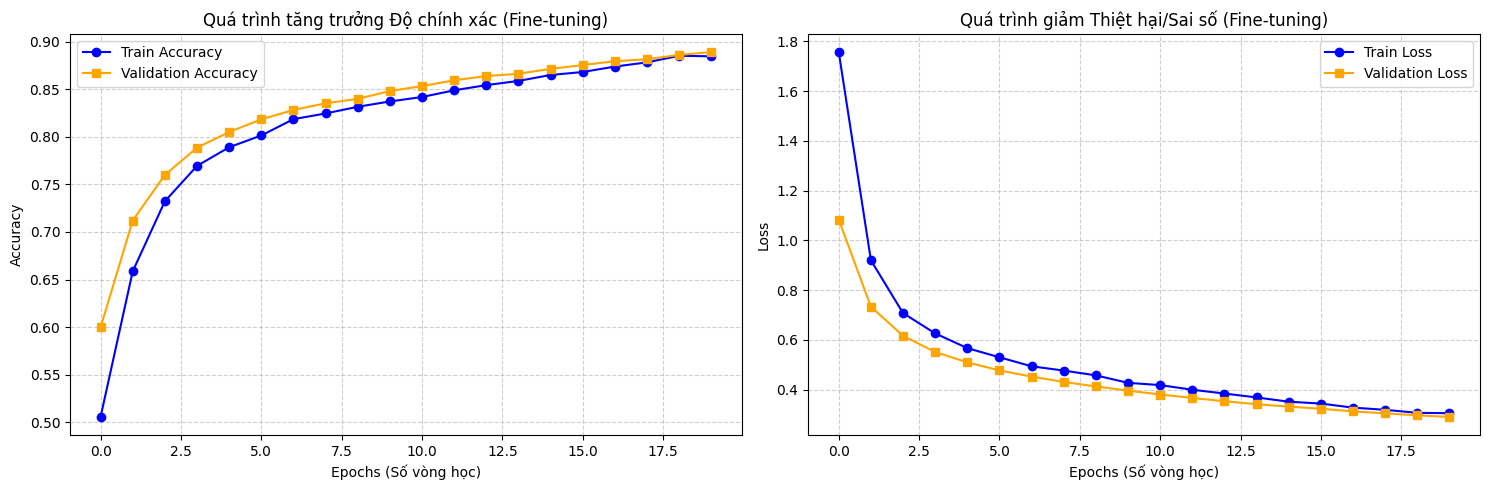

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("⏳ Đang thu thập dự đoán trên tập Final Test...")
# 1. Lấy dự đoán từ mô hình (Xác suất)
y_pred_probs = dl_model.predict(X_final_test)

# 2. Chuyển xác suất thành số nguyên (Class index)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_final_test, axis=1)

# 3. Dịch ngược từ số về tên chữ (VD: 0 -> 'Closed Fist') bằng LabelEncoder (le) đã tạo ở trên
gesture_names = le.inverse_transform(np.unique(y_true_classes))

# ==========================================
# BẰNG CHỨNG 1: BÁO CÁO PHÂN LOẠI CHI TIẾT
# ==========================================
print("\n" + "="*50)
print("📄 BÁO CÁO PHÂN LOẠI CHI TIẾT TỪNG CỬ CHỈ")
print("="*50)
print(classification_report(y_true_classes, y_pred_classes, target_names=gesture_names))

# ==========================================
# BẰNG CHỨNG 2: VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ==========================================
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=gesture_names,
            yticklabels=gesture_names)
plt.title('Confusion Matrix - User Test', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==========================================
# BẰNG CHỨNG 3: VẼ ĐƯỜNG CONG HỌC TẬP (LEARNING CURVES)
# ==========================================
# (Kiểm tra xem quá trình Fine-tuning có ổn định không)
if 'history_finetune' in locals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Vẽ biểu đồ Accuracy
    ax1.plot(history_finetune.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
    ax1.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='s')
    ax1.set_title('Quá trình tăng trưởng Độ chính xác (Fine-tuning)')
    ax1.set_xlabel('Epochs (Số vòng học)')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Vẽ biểu đồ Loss
    ax2.plot(history_finetune.history['loss'], label='Train Loss', color='blue', marker='o')
    ax2.plot(history_finetune.history['val_loss'], label='Validation Loss', color='orange', marker='s')
    ax2.set_title('Quá trình giảm Thiệt hại/Sai số (Fine-tuning)')
    ax2.set_xlabel('Epochs (Số vòng học)')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy dữ liệu history_finetune để vẽ biểu đồ học tập.")